# Tissue preservation — Figure 2G

Path2Space is trained only on fresh-frozen (FF) breast-cancer slides. This
notebook asks whether the model still generalizes to archival **FFPE**
(formalin-fixed paraffin-embedded) tissue — the format the clinic actually
uses — and, if so, which slide-level properties account for whatever
preservation effect remains.

## Two analyses

**Figure 2G — FF vs FFPE prediction accuracy.** Per-section gene-wise PCC
between predicted and measured expression, stratified by preservation method
(FF / FFPE) within the two external cohorts that contain both (HEST and
HTAN). A cohort-adjusted linear mixed-effects model tests whether mean PCC
differs by preservation method.

**Nuclear morphology and accuracy.** For each of eight CellPose-derived
nuclear features (nuclear area, equivalent diameter, circularity, solidity,
eccentricity, aspect ratio, nearest-neighbor distance, local nuclear
density), a per-sample MixedLM tests whether the feature explains
prediction accuracy after controlling for preservation method. Benjamini-
Hochberg FDR is applied across the eight features.

## Setup

In [1]:
import sys; sys.path.insert(0, "../lib")
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ff_ffpe_stats import ff_vs_ffpe_test, morphology_associations, MORPHOLOGY_FEATURES

## Load the bundled tables

`per_sample_gene_pcc.parquet` — one row per (sample, gene) for the HEST and
HTAN external cohorts, restricted to genes present in every sample of the
cohort. This is the violin-plot input.

`per_sample_summary.parquet` — one row per sample (40 QC-pass samples across
all four cohorts): mean predicted-vs-measured PCC, the eight CellPose
morphology features (sample-level means), cohort label, and preservation
method. This is the MixedLM input.

In [2]:
per_gene  = pd.read_parquet("../data/per_sample_gene_pcc.parquet")
summary   = pd.read_parquet("../data/per_sample_summary.parquet")

print(f"per-gene PCC table: {len(per_gene):,} rows, "
      f"{per_gene['sample_ID'].nunique()} samples, {per_gene['gene'].nunique():,} genes")
print(f"per-sample summary: {len(summary)} samples")
print("\ncohort x preservation:"); print(pd.crosstab(summary['cohort'], summary['preservation_method']))

per-gene PCC table: 163,865 rows, 14 samples, 11,933 genes
per-sample summary: 40 samples

cohort x preservation:
preservation_method  FF  FFPE
cohort                       
HEST                  3     2
HTAN                  5     4
TNBC                 22     0
pierre_martinez       4     0


## Figure 2G — violin: per-section PCC, FF vs FFPE

One violin per sample, hue by preservation method. Top panel: HEST
(`NCBI776`, the `TENX*` 10x Visium sections); bottom panel: HTAN.

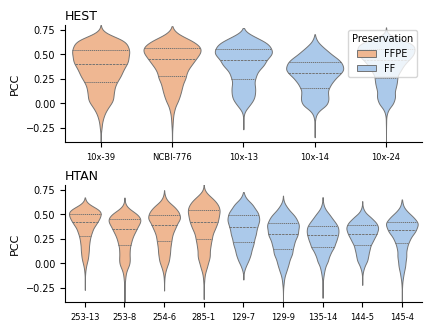

In [3]:
def abbreviate(s):
    import re
    if (m := re.match(r'^HTA\d+_(\d+)_(\d+)$', s)): return f'{m.group(1)}-{m.group(2)}'
    if (m := re.match(r'^TENX(\d+)$', s)):           return f'10x-{m.group(1)}'
    if (m := re.match(r'^NCBI(\d+)$', s)):           return f'NCBI-{m.group(1)}'
    return s

plot = per_gene.copy()
plot['sample_ID'] = plot['sample_ID'].map(abbreviate)

palette = {'FF': sns.color_palette('pastel', 2)[0], 'FFPE': sns.color_palette('pastel', 2)[1]}
fig, axes = plt.subplots(2, 1, figsize=(4.2, 3.2), constrained_layout=True)
for ax, coh in zip(axes, ['HEST', 'HTAN']):
    d = plot[plot.cohort == coh]
    order = (d.sort_values(['preservation_method', 'sample_ID'], ascending=[False, True])
              ['sample_ID'].unique())
    sns.violinplot(data=d, x='sample_ID', y='correlation',
                   hue='preservation_method', hue_order=['FFPE', 'FF'], order=order,
                   palette=palette, linewidth=0.7, density_norm='width', cut=0,
                   inner='quartile', ax=ax)
    ax.set_xlabel(''); ax.set_ylabel('PCC', fontsize=8)
    ax.set_title(coh, loc='left', fontsize=9, pad=4)
    ax.tick_params(axis='x', labelsize=6); ax.tick_params(axis='y', labelsize=7)
    ax.set_ylim(-0.4, 0.8)
axes[1].get_legend().remove()
axes[0].legend(title='Preservation', loc='upper right', fontsize=7, title_fontsize=7)
sns.despine(); plt.show()

## Cohort-adjusted FF vs FFPE test

In [4]:
# External validation = non-training cohorts (HEST, HTAN, pierre_martinez).
external = summary[summary.cohort != 'TNBC']
result = ff_vs_ffpe_test(external)
print(f"external samples used: {result['n']}")
print(f"  median PCC (FF)   = {result['median_FF']:.3f}")
print(f"  median PCC (FFPE) = {result['median_FFPE']:.3f}")
print(f"\nMixedLM mean_pcc ~ FF, groups=cohort:")
print(f"  beta(FF) = {result['beta_FF']:+.3f}")
print(f"  p-value  = {result['pvalue']:.3f}")

external samples used: 18
  median PCC (FF)   = 0.292
  median PCC (FFPE) = 0.368

MixedLM mean_pcc ~ FF, groups=cohort:
  beta(FF) = -0.048
  p-value  = 0.126


## Eight-feature morphology MixedLM

Per feature: `mean_pcc ~ feature + preservation, groups=cohort`. The
coefficient on the morphology feature is the per-unit change in mean PCC
attributable to that feature, after controlling for preservation method and
between-cohort variation.

In [5]:
morph = morphology_associations(summary)
morph.round(4)

,feature,beta,pvalue,n,fdr
0,eccentricity,-1.4923,0.0114,40,0.0913
1,aspect_ratio,-0.4267,0.0247,40,0.0990
2,circularity,1.4104,0.0638,40,0.1701
3,nearest_neighbor_distance,0.0034,0.1697,40,0.3328
4,nuclear_area,-0.0008,0.2204,40,0.3328
5,equivalent_diameter,-0.0173,0.2496,40,0.3328
6,nuclear_density_local,-0.0009,0.6183,40,0.6432
7,solidity,-2.2604,0.6432,40,0.6432


In [6]:
# Sort the table by p-value and report the top feature.
top = morph.iloc[0]
print(f"strongest association: {top['feature']}  beta = {top['beta']:+.2f}  "
      f"p = {top['pvalue']:.4g}  fdr = {top['fdr']:.4g}  (n = {int(top['n'])})")

strongest association: eccentricity  beta = -1.49  p = 0.01141  fdr = 0.09132  (n = 40)


## Eccentricity vs PCC, per cohort

Supporting plot for the morphology finding: per-sample eccentricity vs mean
PCC, one panel per cohort, points coloured by preservation method. A
negative slope means more-eccentric (elongated) nuclei are associated with
lower prediction accuracy.

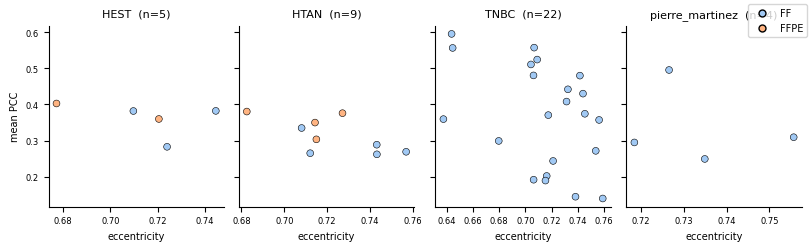

In [7]:
plot_data = summary[['eccentricity', 'mean_pcc', 'preservation_method', 'cohort']].dropna()
cohorts = sorted(plot_data['cohort'].unique())
ncol = min(4, len(cohorts))
nrow = int(np.ceil(len(cohorts) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(2.0 * ncol, 2.4 * nrow),
                         squeeze=False, sharey=True, constrained_layout=True)
palette = {'FF': sns.color_palette('pastel', 2)[0], 'FFPE': sns.color_palette('pastel', 2)[1]}
for i, coh in enumerate(cohorts):
    ax = axes.flat[i]
    d = plot_data[plot_data.cohort == coh]
    sns.scatterplot(data=d, x='eccentricity', y='mean_pcc',
                    hue='preservation_method', palette=palette, s=24,
                    edgecolor='black', linewidth=0.4, ax=ax)
    ax.set_title(f'{coh}  (n={len(d)})', fontsize=8)
    ax.set_xlabel('eccentricity', fontsize=7); ax.set_ylabel('mean PCC', fontsize=7)
    ax.tick_params(labelsize=6)
    if ax.get_legend(): ax.get_legend().remove()
for j in range(len(cohorts), nrow*ncol): axes.flat[j].set_visible(False)
handles = [plt.Line2D([0],[0], marker='o', linestyle='', markersize=5,
                      markerfacecolor=palette[k], markeredgecolor='black') for k in ['FF','FFPE']]
fig.legend(handles, ['FF','FFPE'], loc='upper right', fontsize=7, frameon=True)
sns.despine(); plt.show()

## Takeaway

Within the cohorts that contain both preservation methods, predicted-vs-
measured PCC distributions are broadly overlapping across FF and FFPE
sections (Fig 2G), and after adjusting for cohort the difference in mean
PCC between the two preservation methods is small relative to between-
cohort variation. Of the eight nuclear-morphology features, eccentricity
carries the strongest negative association with accuracy — slides with
more-elongated nuclei tend to be predicted somewhat less well, consistent
with that feature being the most preservation-sensitive aspect of nuclear
shape captured by CellPose. The two findings together: FF and FFPE
generalize comparably, and the preservation effect that does remain tracks
nuclear shape, not cohort identity.